Jason Stys

In [ ]:
# CA9 Load Dependencies

import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

# Text + NLP
import nltk
from nltk.corpus import reuters, stopwords
from nltk.tokenize import word_tokenize

# Gensim for word2vec + bigrams
# Install gensim if not already installed
!pip install gensim
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser

# Dimensionality reduction for visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Download NLTK data (only runs the first time)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("reuters")
nltk.download("punkt_tab") # Added to download the missing resource

print("Dependencies loaded.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Dependencies loaded.


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# CA9 Load Data

# Reuters has ~11k news documents
file_ids = reuters.fileids()
print(f"Number of Reuters documents: {len(file_ids)}")

# For speed in class, we can subsample
# Set this to None to use all documents.
MAX_DOCS = 200

if MAX_DOCS is not None:
    file_ids = file_ids[:MAX_DOCS]

corpus_raw_docs = [reuters.raw(fid) for fid in file_ids]

print(f"Using {len(corpus_raw_docs)} documents in the corpus.")
print("\n--- Sample document preview ---")
print(corpus_raw_docs[0][:500])

Number of Reuters documents: 10788
Using 200 documents in the corpus.

--- Sample document preview ---
ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT
  Mounting trade friction between the
  U.S. And Japan has raised fears among many of Asia's exporting
  nations that the row could inflict far-reaching economic
  damage, businessmen and officials said.
      They told Reuter correspondents in Asian capitals a U.S.
  Move against Japan might boost protectionist sentiment in the
  U.S. And lead to curbs on American imports of their products.
      But some exporters said that while the conflict wo


In [ ]:
# CA9 Preprocess a sentence

STOP_WORDS = set(stopwords.words("english"))

def preprocess_sentence(text):
    """
    Basic preprocessing:
    - lowercase
    - keep letters and spaces only
    - tokenize
    - remove stopwords and 1-character tokens
    """
    # lowercase
    text = text.lower()
    # keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    # tokenize
    tokens = word_tokenize(text)
    # remove stop words + very short tokens
    tokens = [tok for tok in tokens if tok not in STOP_WORDS and len(tok) > 1]
    return tokens

# Quick test on a single sentence
test_sentence = "The quick brown fox jumps over the lazy dog in New York City."
print("Original:", test_sentence)
print("Preprocessed:", preprocess_sentence(test_sentence))

Original: The quick brown fox jumps over the lazy dog in New York City.
Preprocessed: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog', 'new', 'york', 'city']


In [ ]:
# CA9 Handles bigram

def build_bigrams(tokenized_sentences, min_count=10, threshold=10.0):
    """
    Learn bigram phrases from a list of tokenized sentences
    and return the bigram transformer (Phraser) plus transformed sentences.
    """
    phrases = Phrases(tokenized_sentences,
                      min_count=min_count,
                      threshold=threshold,
                      progress_per=10000)
    bigram = Phraser(phrases)
    sentences_with_bigrams = [bigram[sent] for sent in tokenized_sentences]
    return bigram, sentences_with_bigrams

# Tiny demo on a few sentences
demo_sents = [
    preprocess_sentence("New York City is a major financial center."),
    preprocess_sentence("The New York Stock Exchange is in New York City."),
    preprocess_sentence("I visited New York last summer.")
]

bigram_model_demo, demo_bigrams = build_bigrams(demo_sents, min_count=1, threshold=1.0)

print("Demo sentences with bigrams:")
for s in demo_bigrams:
    print(s)

Demo sentences with bigrams:
['new_york', 'city', 'major', 'financial', 'center']
['new_york', 'stock', 'exchange', 'new_york', 'city']
['visited', 'new_york', 'last', 'summer']


In [ ]:
# CA9 Preprocess corpus

# 1. Tokenize and clean each document
tokenized_docs = [preprocess_sentence(doc) for doc in corpus_raw_docs]

# Remove any empty docs
tokenized_docs = [doc for doc in tokenized_docs if len(doc) > 0]

print(f"Number of non-empty documents: {len(tokenized_docs)}")

# 2. Build and apply bigrams
bigram_model, tokenized_docs_bigram = build_bigrams(tokenized_docs,
                                                    min_count=5,
                                                    threshold=10.0)

print("Example document tokens (first 40 tokens):")
print(tokenized_docs_bigram[0][:40])

# 3. Flatten into sentences for word2vec
sentences_for_w2v = tokenized_docs_bigram

print(f"Number of sentences for word2vec training: {len(sentences_for_w2v)}")

Number of non-empty documents: 200
Example document tokens (first 40 tokens):
['asian', 'exporters', 'fear', 'damage', 'japan', 'rift', 'mounting', 'trade', 'friction', 'japan', 'raised', 'fears', 'among', 'many', 'asia', 'exporting', 'nations', 'row', 'could', 'inflict', 'far', 'reaching', 'economic', 'damage', 'businessmen', 'officials', 'said', 'told', 'reuter', 'correspondents', 'asian', 'capitals', 'move', 'japan', 'might', 'boost', 'protectionist', 'sentiment', 'lead', 'curbs']
Number of sentences for word2vec training: 200


In [ ]:
# CA9 Modle Traing

w2v_size = 100      # embedding dimensionality
w2v_window = 5      # context window size
w2v_min_count = 5   # ignore words with total frequency lower than this
w2v_workers = 4     # number of worker threads
w2v_epochs = 10     # training epochs

word2vec_model = Word2Vec(
    sentences=sentences_for_w2v,
    vector_size=w2v_size,
    window=w2v_window,
    min_count=w2v_min_count,
    workers=w2v_workers,
    sg=1,             # sg=1 => skip-gram; sg=0 => CBOW
    negative=10,      # negative sampling
    seed=42
)

word2vec_model.train(sentences_for_w2v,
                     total_examples=len(sentences_for_w2v),
                     epochs=w2v_epochs)

print("Word2Vec model trained.")
print(f"Vocab size: {len(word2vec_model.wv.key_to_index)}")

word2vec_model.save("ca9_reuters_word2vec.model")

Word2Vec model trained.
Vocab size: 829


In [ ]:
# CA9 Explore saved model


vocab = list(word2vec_model.wv.key_to_index.keys())
print(f"Vocab size: {len(vocab)}")

# Show a few most frequent words
print("\nMost frequent words:")
for word, idx in list(word2vec_model.wv.key_to_index.items())[:20]:
    print(word)

# Try some similarity queries (words present in Reuters)
probe_words = ["bank", "oil", "market", "company", "trade"]

for w in probe_words:
    if w in word2vec_model.wv:
        print(f"\nWords most similar to '{w}':")
        for sim_word, score in word2vec_model.wv.most_similar(w, topn=10):
            print(f"  {sim_word:15s}  {score:.3f}")
    else:
        print(f"\n'{w}' not in vocabulary.")

Vocab size: 829

Most frequent words:
said
mln
pct
vs
dlrs
company
lt
year
would
trade
tonnes
mln_dlrs
japan
also
market
shares
bank
share
new
two

Words most similar to 'bank':
  bought           0.917
  money_market     0.901
  band             0.896
  bills            0.886
  mln_stg          0.870
  sumitomo         0.849
  treasury         0.812
  komatsu          0.792
  three            0.785
  addition         0.779

Words most similar to 'oil':
  palm             0.850
  kuwait           0.829
  better           0.826
  malaysia         0.799
  country          0.797
  product          0.796
  sun              0.794
  low              0.791
  prices           0.789
  plants           0.785

Words most similar to 'market':
  beer             0.886
  funds            0.885
  world            0.879
  interest_rates   0.877
  noted            0.876
  cocoa            0.875
  within           0.872
  offset           0.868
  soon             0.868
  inflation        0.866

Words mo

In [ ]:
# CA9 Reduce dimensionality

# Pick a subset of frequent words to visualize
NUM_WORDS_TO_VIS = 200

# Sort by frequency (appears as index order in key_to_index)
sorted_vocab = sorted(word2vec_model.wv.key_to_index.items(),
                      key=lambda kv: kv[1])
words_to_vis = [w for w, _ in sorted_vocab[:NUM_WORDS_TO_VIS]]

print(f"Visualizing {len(words_to_vis)} words.")

# Get their vectors
X = np.array([word2vec_model.wv[w] for w in words_to_vis])

# --- PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)


Visualizing 200 words.


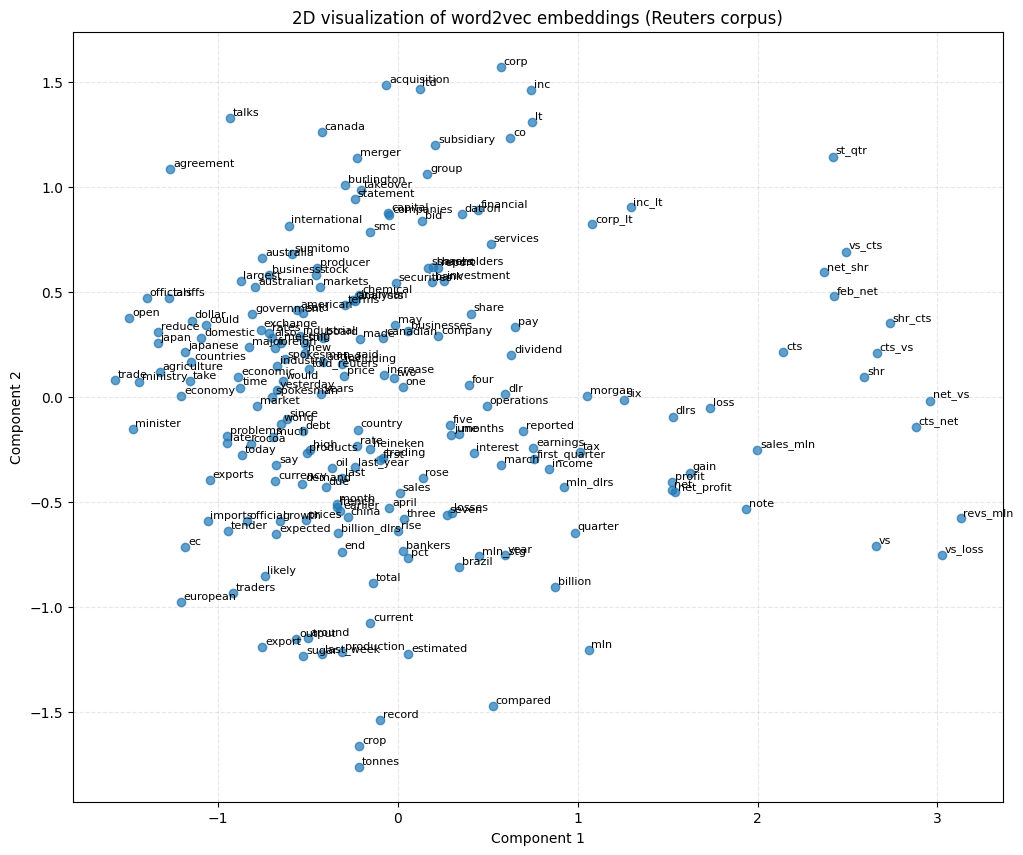

In [ ]:
# CA9 Visualization

plt.figure(figsize=(12, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

for i, word in enumerate(words_to_vis):
    plt.annotate(word,
                 xy=(X_pca[i, 0], X_pca[i, 1]),
                 xytext=(2, 2),
                 textcoords="offset points",
                 fontsize=8)

plt.title("2D visualization of word2vec embeddings (Reuters corpus)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()